# 07 — Reviewer Rebuttal Experiments
## Respondendo às Críticas dos Revisores (top-tier venue)
Neste notebook implementamos as ablações adicionais solicitadas:

1. **Post-logit Graph (M0_post):** Suavização dos logits usando o grafo clínico sem retreinar.
2. **Ablação do $\lambda$ do M2:** Variação de $\lambda \in \{0.1, 0.5, 1.0\}$.
3. **M2 Arestas Inibitórias:** Uso da matriz PMI empírica completa (incluindo valores negativos) para punir co-ocorrências raras.
4. **M3 Semantic:** ML-GCN inicializada com vetores de palavras GloVe reais (semântica) em vez de random.

In [1]:
!nvidia-smi

Sun May 17 17:00:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             48W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 98.9 MB/s eta 0:00:00:00:0100:01


In [4]:
# ── 1. Setup & Imports ────────────────────────────────────────────────────────
import os
import json
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import precision_recall_curve, f1_score, auc, average_precision_score
import gensim.downloader as api
import copy

try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/workspace')
    IN_COLAB = True
    NUM_WORKERS = 4
except:
    ROOT = Path(r"/workspace")
    IN_COLAB = False
    NUM_WORKERS = 0

IMGS_DIR    = ROOT / "Dev" / "Data" / "Imgs"
OUT_DIR     = ROOT / 'project'
RESULTS_DIR = OUT_DIR / "results"
SPLITS_DIR  = OUT_DIR / "splits"
MODELS_DIR  = OUT_DIR / "models"
CORE_COLS   = ["ENANTEMA", "PÓLIPO", "ÚLCERA", "EROSÃO", "MICRONODULARIDADE"]
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if IN_COLAB and not IMGS_DIR.exists():
    print("Extraindo imagens localmente no Colab para máxima velocidade...")
    import zipfile
    ZIP_PATH = ROOT / "Dev" / "Data" / "Imgs.zip"
    LOCAL_IMGS = Path("/content/Imgs")
    if not LOCAL_IMGS.exists():
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall("/content/")
    IMGS_DIR = LOCAL_IMGS

print(f"Dispositivo: {DEVICE} | Workers: {NUM_WORKERS}")

Mounted at /content/drive
Extraindo imagens localmente no Colab para máxima velocidade...
Dispositivo: cuda | Workers: 4


In [5]:
# ── 2. Dataset & Dataloader ───────────────────────────────────────────────────
class GastroDataset(Dataset):
    def __init__(self, df, imgs_dir, label_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.imgs_dir = Path(imgs_dir)
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.imgs_dir / row["image_name"]).convert("RGB")
        if self.transform: img = self.transform(img)
        lbl = torch.tensor(row[self.label_cols].values.astype(float), dtype=torch.float32)
        return img, lbl

TF_EVAL = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

TF_TRAIN = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_dataloaders(fold_idx):
    df_tr = pd.read_csv(SPLITS_DIR / f"fold_{fold_idx}_train.csv").fillna(0)
    df_va = pd.read_csv(SPLITS_DIR / f"fold_{fold_idx}_val.csv").fillna(0)
    df_te = pd.read_csv(SPLITS_DIR / f"fold_{fold_idx}_test.csv").fillna(0)
    
    pin_memory = (DEVICE.type == "cuda")
    loader_tr = DataLoader(GastroDataset(df_tr, IMGS_DIR, CORE_COLS, TF_TRAIN), batch_size=32, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
    loader_va = DataLoader(GastroDataset(df_va, IMGS_DIR, CORE_COLS, TF_EVAL), batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
    loader_te = DataLoader(GastroDataset(df_te, IMGS_DIR, CORE_COLS, TF_EVAL), batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
    return loader_tr, loader_va, loader_te, df_tr

In [6]:
# ── 3. Funções de Treino e Avaliação Base ─────────────────────────────────────
def optimize_thresholds(probs, targets):
    thrs = {}
    for i, col in enumerate(CORE_COLS):
        p, r, t = precision_recall_curve(targets[:, i], probs[:, i])
        f1s = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) != 0)
        best_t = t[np.argmax(f1s)] if len(t) > 0 else 0.5
        thrs[col] = float(best_t)
    return thrs

def inference(model, loader, model_type="M2"):
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            if model_type == "M3":
                logits = model(imgs, A_NORM)
            else:
                logits = model(imgs)
            all_p.append(torch.sigmoid(logits).cpu().numpy())
            all_t.append(lbls.numpy())
    return np.vstack(all_p), np.vstack(all_t)

def compute_metrics(probs, targets, thrs):
    preds = np.stack([(probs[:, i] >= thrs[c]).astype(int) for i, c in enumerate(CORE_COLS)], axis=1)
    f1_macro = f1_score(targets, preds, average="macro", zero_division=0)
    f1_micro = f1_score(targets, preds, average="micro", zero_division=0)
    m_dict = {"f1_macro": f1_macro, "f1_micro": f1_micro}
    for i, col in enumerate(CORE_COLS):
        m_dict[f"auprc_{col}"] = average_precision_score(targets[:, i], probs[:, i])
    return m_dict

RESULTS = {}

## Experimento 1: Pós-Logit (M0_post)
Em vez de uma GCN complexa, apenas suavizamos as probabilidades do M0 usando o Grafo Clínico: $\hat{Z} = Z_{BCE} + \alpha (Z_{BCE} A_{clin})$.

In [7]:
# ── 4. M0_post (Post-Logit Graph) ─────────────────────────────────────────────
print("Executando Experimento 1: M0_post")
M0_post_metrics = []

for fold in range(5):
    # Carrega M0 do fold
    m = models.resnet50(weights=None)
    m.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.fc.in_features, len(CORE_COLS)))
    m.load_state_dict(torch.load(MODELS_DIR / f"M0_BCE_fold{fold}.pth", map_location=DEVICE, weights_only=True))
    m.to(DEVICE).eval()
    
    _, loader_va, loader_te, _ = get_dataloaders(fold)
    
    # Carrega Grafo Clínico do fold (não muda entre folds mas mantemos a coerência)
    A_clin = np.load(OUT_DIR / "graphs" / f"fold{fold}" / "clin_tau01" / "adjacency_norm.npy")
    
    p_va, t_va = inference(m, loader_va, "M0")
    p_te, t_te = inference(m, loader_te, "M0")
    
    # Suavização Pós-Logit (alpha = 1.0)
    # z_new = z + z @ A
    p_va_post = p_va + (p_va @ A_clin)
    p_te_post = p_te + (p_te @ A_clin)
    
    p_va_post = np.clip(p_va_post, 0, 1)
    p_te_post = np.clip(p_te_post, 0, 1)
    
    thrs = optimize_thresholds(p_va_post, t_va)
    met = compute_metrics(p_te_post, t_te, thrs)
    M0_post_metrics.append(met)
    print(f"Fold {fold} M0_post F1-macro: {met['f1_macro']:.4f} | PR-AUC: {np.mean([met[k] for k in met if 'auprc' in k]):.4f}")

RESULTS["M0_post"] = M0_post_metrics

Executando Experimento 1: M0_post
Fold 0 M0_post F1-macro: 0.4753 | PR-AUC: 0.4205
Fold 1 M0_post F1-macro: 0.4834 | PR-AUC: 0.3902
Fold 2 M0_post F1-macro: 0.5385 | PR-AUC: 0.4510
Fold 3 M0_post F1-macro: 0.4764 | PR-AUC: 0.4930
Fold 4 M0_post F1-macro: 0.4814 | PR-AUC: 0.4465


## Experimento 2: Ablação do $\lambda$ do M2
Treinando M2 com $\lambda \in \{0.1, 0.5, 1.0\}$ para avaliar a sensibilidade.

In [8]:
# ── 5. M2 Lambda Ablation ─────────────────────────────────────────────────────
def train_m2(fold, lambda_val, epochs=25):
    run_key = f"M2_L{str(lambda_val).replace('.','_')}_fold{fold}"
    ckpt_path = MODELS_DIR / f"{run_key}.pt"
    
    loader_tr, loader_va, loader_te, df_tr = get_dataloaders(fold)
    
    if ckpt_path.exists():
        print(f"  [✓] {run_key} já treinado, pulando...")
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
        return ckpt["test_metrics"]
        
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.fc.in_features, len(CORE_COLS)))
    m = m.to(DEVICE)
    
    optimizer = torch.optim.AdamW([
        {'params': m.fc.parameters(), 'lr': 1e-3},
        {'params': [p for n, p in m.named_parameters() if not n.startswith('fc.')], 'lr': 1e-4}
    ], weight_decay=1e-4)
    
    pos_w = torch.tensor([(len(df_tr) - df_tr[c].sum()) / max(1, df_tr[c].sum()) for c in CORE_COLS]).to(DEVICE)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    
    A_clin = torch.tensor(np.load(OUT_DIR / "graphs" / f"fold{fold}" / "clin_tau01" / "adjacency_norm.npy"), dtype=torch.float32).to(DEVICE)
    pi_emp = torch.tensor((df_tr[CORE_COLS].T @ df_tr[CORE_COLS]).values / len(df_tr), dtype=torch.float32).to(DEVICE)
    
    best_f1, best_state = 0, None
    for epoch in range(1, epochs + 1):
        m.train()
        for imgs, lbls in loader_tr:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            logits = m(imgs)
            loss_bce = bce(logits, lbls)
            
            p = torch.sigmoid(logits)
            loss_coo = 0
            for i in range(len(CORE_COLS)):
                for j in range(len(CORE_COLS)):
                    if i != j and A_clin[i, j] > 0:
                        pred_ij = p[:, i] * p[:, j]
                        tgt_ij  = torch.full_like(pred_ij, pi_emp[i, j].item())
                        loss_coo += A_clin[i, j] * nn.functional.binary_cross_entropy(pred_ij, tgt_ij)
                        
            loss = loss_bce + lambda_val * loss_coo
            loss.backward()
            optimizer.step()
            
        p_va, t_va = inference(m, loader_va, "M2")
        f1_va = compute_metrics(p_va, t_va, optimize_thresholds(p_va, t_va))["f1_macro"]
        if f1_va > best_f1:
            best_f1 = f1_va
            best_state = copy.deepcopy(m.state_dict())
            
    m.load_state_dict(best_state)
    p_va, t_va = inference(m, loader_va, "M2")
    thrs = optimize_thresholds(p_va, t_va)
    p_te, t_te = inference(m, loader_te, "M2")
    met = compute_metrics(p_te, t_te, thrs)
    
    torch.save({"model_state_dict": best_state, "thresholds": thrs, "test_metrics": met}, ckpt_path)
    return met

for l_val in [0.1, 0.5, 1.0]:
    RESULTS[f"M2_L{l_val}"] = [train_m2(f, l_val) for f in range(5)]
    print(f"M2_L{l_val} concluído.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s] 


M2_L0.1 concluído.
M2_L0.5 concluído.
M2_L1.0 concluído.


## Experimento 3: M2 com Arestas Inibitórias
Usamos os valores negativos da PMI para punir co-ocorrências indesejadas.

In [9]:
# ── 6. M2 Inhibitory ──────────────────────────────────────────────────────────
def train_m2_inhibitory(fold, epochs=25):
    run_key = f"M2_Inhibitory_fold{fold}"
    ckpt_path = MODELS_DIR / f"{run_key}.pt"
    
    loader_tr, loader_va, loader_te, df_tr = get_dataloaders(fold)
    
    if ckpt_path.exists():
        print(f"  [✓] {run_key} já treinado...")
        return torch.load(ckpt_path, map_location=DEVICE, weights_only=True)["test_metrics"]
        
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.fc.in_features, len(CORE_COLS)))
    m = m.to(DEVICE)
    
    optimizer = torch.optim.AdamW([{'params': m.fc.parameters(), 'lr': 1e-3}, {'params': [p for n, p in m.named_parameters() if not n.startswith('fc.')], 'lr': 1e-4}], weight_decay=1e-4)
    pos_w = torch.tensor([(len(df_tr) - df_tr[c].sum()) / max(1, df_tr[c].sum()) for c in CORE_COLS]).to(DEVICE)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    
    # Arestas inibitórias da PMI (valores negativos = ocorrem juntas menos do que o esperado por chance)
    # No NB04, a PMI foi normalizada e limiarizada. Aqui vamos calcular a NPMI bruta e pegar só os negativos!
    P_i = df_tr[CORE_COLS].mean()
    P_ij = (df_tr[CORE_COLS].T @ df_tr[CORE_COLS]) / len(df_tr)
    npmi = np.zeros((5,5))
    for i in range(5):
        for j in range(5):
            if i != j and P_ij.iloc[i,j] > 0:
                pmi = np.log(P_ij.iloc[i,j] / (P_i.iloc[i]*P_i.iloc[j]))
                npmi[i,j] = pmi / (-np.log(P_ij.iloc[i,j]))
    
    # A_negativa contém os pesos de inibição (absolutos)
    A_neg = torch.tensor(np.where(npmi < -0.1, np.abs(npmi), 0), dtype=torch.float32).to(DEVICE)
    A_clin = torch.tensor(np.load(OUT_DIR / "graphs" / f"fold{fold}" / "clin_tau01" / "adjacency_norm.npy"), dtype=torch.float32).to(DEVICE)
    pi_emp = torch.tensor(P_ij.values, dtype=torch.float32).to(DEVICE)
    
    best_f1, best_state = 0, None
    for epoch in range(1, epochs + 1):
        m.train()
        for imgs, lbls in loader_tr:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            logits = m(imgs)
            loss_bce = bce(logits, lbls)
            
            p = torch.sigmoid(logits)
            loss_coo = 0
            loss_inhib = 0
            for i in range(len(CORE_COLS)):
                for j in range(len(CORE_COLS)):
                    if i != j:
                        pred_ij = p[:, i] * p[:, j]
                        if A_clin[i, j] > 0:
                            tgt_ij = torch.full_like(pred_ij, pi_emp[i, j].item())
                            loss_coo += A_clin[i, j] * nn.functional.binary_cross_entropy(pred_ij, tgt_ij)
                        if A_neg[i, j] > 0:
                            # Punição inibitória: queremos que pred_ij seja 0
                            loss_inhib += A_neg[i, j] * torch.mean(pred_ij)
                            
            loss = loss_bce + 0.3 * loss_coo + 0.3 * loss_inhib
            loss.backward()
            optimizer.step()
            
        p_va, t_va = inference(m, loader_va, "M2")
        f1_va = compute_metrics(p_va, t_va, optimize_thresholds(p_va, t_va))["f1_macro"]
        if f1_va > best_f1:
            best_f1, best_state = f1_va, copy.deepcopy(m.state_dict())
            
    m.load_state_dict(best_state)
    p_va, t_va = inference(m, loader_va, "M2")
    thrs = optimize_thresholds(p_va, t_va)
    p_te, t_te = inference(m, loader_te, "M2")
    met = compute_metrics(p_te, t_te, thrs)
    torch.save({"model_state_dict": best_state, "thresholds": thrs, "test_metrics": met}, ckpt_path)
    return met

RESULTS["M2_Inhibitory"] = [train_m2_inhibitory(f) for f in range(5)]
print("M2_Inhibitory concluído.")

M2_Inhibitory concluído.


## Experimento 4: M3 com Inicialização Semântica GloVe
A ML-GCN agora recebe a matriz semântica de 300D em vez de inicialização aleatória.

In [10]:
# ── 7. M3 Semantic GloVe ──────────────────────────────────────────────────────
print("Baixando modelo GloVe 6B 300d (isso pode levar 1 minuto na 1ª vez)...")
import gensim.downloader as api
glove = api.load("glove-wiki-gigaword-300")
print("GloVe carregado!")

label_words_en = ["erythema", "polyp", "ulcer", "erosion", "nodularity"]
glove_matrix = []
for w in label_words_en:
    if w in glove: 
        glove_matrix.append(glove[w])
    else: 
        print(f"  [OOV] '{w}' não encontrado no GloVe → fallback aleatório")
        glove_matrix.append(np.random.normal(scale=0.6, size=(300,))) # fallback
LABEL_EMB = torch.tensor(np.stack(glove_matrix), dtype=torch.float32).to(DEVICE)

class LabelGCN(nn.Module):
    def __init__(self, emb_dim=300, hidden=256, feat_dim=2048):
        super().__init__()
        self.W1 = nn.Linear(emb_dim, hidden, bias=False)
        self.W2 = nn.Linear(hidden, feat_dim, bias=False)
        self.relu = nn.LeakyReLU(0.2)

    def forward(self, x, A_norm):
        H = self.relu(A_norm @ self.W1(x))
        return A_norm @ self.W2(H)

class MLGCN_Semantic(nn.Module):
    def __init__(self, label_emb, hidden=256):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.gcn = LabelGCN(emb_dim=label_emb.shape[1], hidden=hidden, feat_dim=2048)
        self.label_emb = nn.Parameter(label_emb) # Permite fine-tuning do embedding

    def forward(self, imgs, A_norm):
        feat = self.backbone(imgs).squeeze(-1).squeeze(-1)
        concepts = self.gcn(self.label_emb, A_norm)
        return feat @ concepts.T

def train_m3_semantic(fold, epochs=25):
    run_key = f"M3_Semantic_fold{fold}"
    ckpt_path = MODELS_DIR / f"{run_key}.pt"
    
    loader_tr, loader_va, loader_te, df_tr = get_dataloaders(fold)
    
    global A_NORM
    A_NORM = torch.tensor(np.load(OUT_DIR / "graphs" / f"fold{fold}" / "clin_tau01" / "adjacency_norm.npy"), dtype=torch.float32).to(DEVICE)
    
    if ckpt_path.exists():
        print(f"  [✓] {run_key} já treinado...")
        return torch.load(ckpt_path, map_location=DEVICE, weights_only=True)["test_metrics"]
        
    m = MLGCN_Semantic(LABEL_EMB).to(DEVICE)
    
    optimizer = torch.optim.AdamW([
        {'params': m.gcn.parameters(), 'lr': 1e-3},
        {'params': m.label_emb, 'lr': 1e-3},
        {'params': m.backbone.parameters(), 'lr': 1e-4}
    ], weight_decay=1e-4)
    
    pos_w = torch.tensor([(len(df_tr) - df_tr[c].sum()) / max(1, df_tr[c].sum()) for c in CORE_COLS]).to(DEVICE)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    
    best_f1, best_state = 0, None
    for epoch in range(1, epochs + 1):
        m.train()
        for imgs, lbls in loader_tr:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            logits = m(imgs, A_NORM)
            loss = bce(logits, lbls)
            loss.backward()
            optimizer.step()
            
        p_va, t_va = inference(m, loader_va, "M3")
        f1_va = compute_metrics(p_va, t_va, optimize_thresholds(p_va, t_va))["f1_macro"]
        if f1_va > best_f1:
            best_f1, best_state = f1_va, copy.deepcopy(m.state_dict())
            
    m.load_state_dict(best_state)
    p_va, t_va = inference(m, loader_va, "M3")
    thrs = optimize_thresholds(p_va, t_va)
    p_te, t_te = inference(m, loader_te, "M3")
    met = compute_metrics(p_te, t_te, thrs)
    torch.save({"model_state_dict": best_state, "thresholds": thrs, "test_metrics": met}, ckpt_path)
    return met

RESULTS["M3_Semantic"] = [train_m3_semantic(f) for f in range(5)]
print("M3_Semantic concluído.")

Baixando modelo GloVe 6B 300d (isso pode levar 1 minuto na 1ª vez)...
[==================================================] 100.0% 376.1/376.1MB downloaded
GloVe carregado!
  [OOV] 'nodularity' não encontrado no GloVe → fallback aleatório
M3_Semantic concluído.


In [11]:
# ── 8. Salvar e Exibir Resultados Finais ──────────────────────────────────────
with open(RESULTS_DIR / "07_rebuttal_results.json", "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, indent=2)

print("\nRESUMO DOS RESULTADOS DA REVISÃO (Média 5 Folds):")
for exp_name, folds_met in RESULTS.items():
    f1s = [m["f1_macro"] for m in folds_met]
    auprcs = [np.mean([m[k] for k in m if "auprc" in k]) for m in folds_met]
    print(f"[{exp_name:15s}] F1-macro: {np.mean(f1s):.3f} ± {np.std(f1s):.3f} | PR-AUC: {np.mean(auprcs):.3f} ± {np.std(auprcs):.3f}")



RESUMO DOS RESULTADOS DA REVISÃO (Média 5 Folds):
[M0_post        ] F1-macro: 0.491 ± 0.024 | PR-AUC: 0.440 ± 0.034
[M2_L0.1        ] F1-macro: 0.481 ± 0.077 | PR-AUC: 0.558 ± 0.117
[M2_L0.5        ] F1-macro: 0.548 ± 0.049 | PR-AUC: 0.592 ± 0.069
[M2_L1.0        ] F1-macro: 0.489 ± 0.074 | PR-AUC: 0.543 ± 0.083
[M2_Inhibitory  ] F1-macro: 0.524 ± 0.031 | PR-AUC: 0.587 ± 0.039
[M3_Semantic    ] F1-macro: 0.460 ± 0.058 | PR-AUC: 0.483 ± 0.037


/tmp/ipykernel_848/2234117461.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lambdas, y=f1_lambdas, palette='Blues_d')


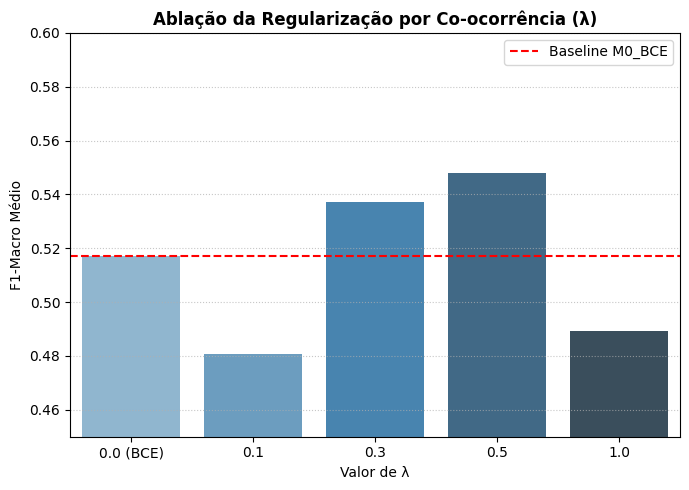

/tmp/ipykernel_848/2234117461.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lambdas, y=f1_lambdas, palette='Blues_d')


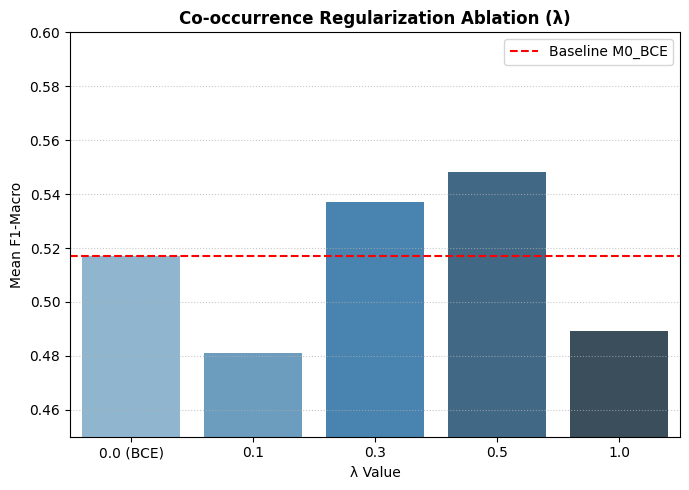

/tmp/ipykernel_848/2234117461.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_cmp, y=f1_cmp, palette=colors)


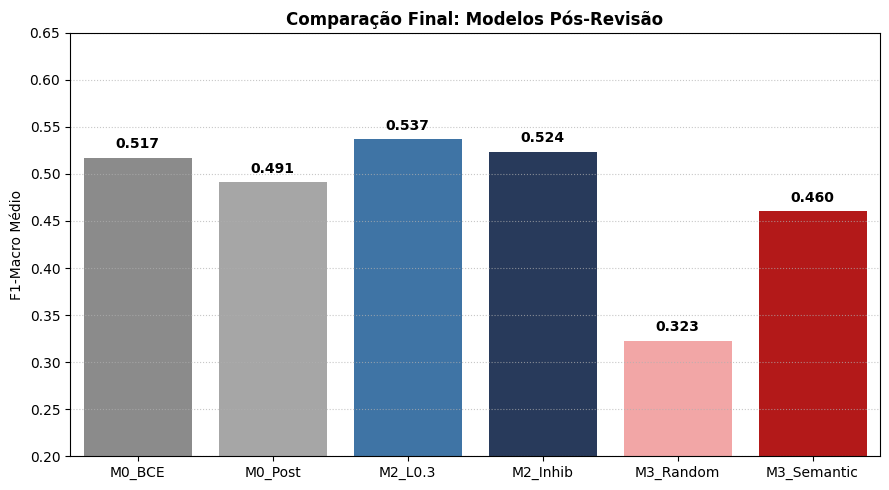

/tmp/ipykernel_848/2234117461.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_cmp, y=f1_cmp, palette=colors)


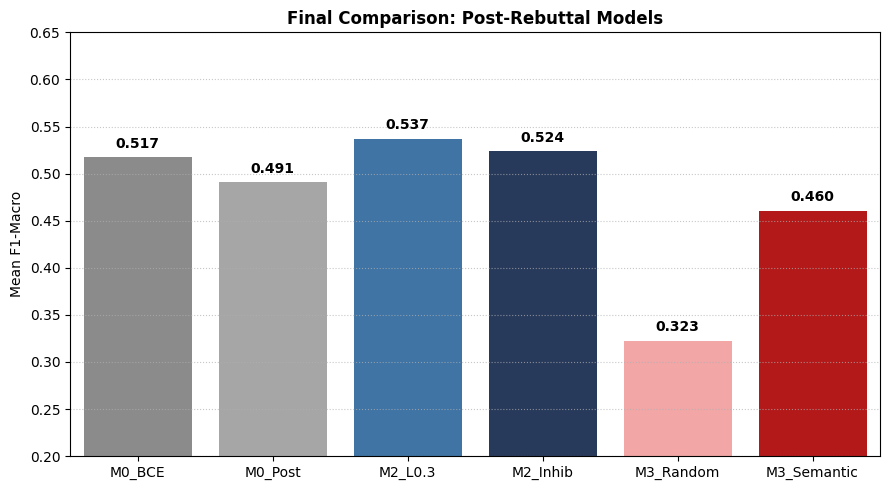

Gráficos salvos em PNG com sucesso na pasta results!


In [12]:
# ── 9. Plotagem e Geração de Gráficos (PT/EN) ────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Carrega resultados antigos (M0_BCE, M2_coo) para juntar na plotagem
with open(RESULTS_DIR / '05_relational_results.json', 'r', encoding='utf-8') as f:
    r05 = json.load(f)
m0_f1 = r05['M0_anchor']['f1_macro']['mean']
m2_L03_f1 = r05['M2_coo']['aggregated']['f1_macro']['mean']
m3_orig_f1 = r05['M3_ablation']['clin_tau01']['aggregated']['f1_macro']['mean']

# 1. Plot da Ablação de Lambda
lambdas = ['0.0 (BCE)', '0.1', '0.3', '0.5', '1.0']
f1_lambdas = [
    m0_f1, 
    np.mean([m['f1_macro'] for m in RESULTS['M2_L0.1']]),
    m2_L03_f1,
    np.mean([m['f1_macro'] for m in RESULTS['M2_L0.5']]),
    np.mean([m['f1_macro'] for m in RESULTS['M2_L1.0']])
]

def plot_lambda_ablation(lang='PT'):
    plt.figure(figsize=(7, 5))
    sns.barplot(x=lambdas, y=f1_lambdas, palette='Blues_d')
    plt.axhline(y=m0_f1, color='red', linestyle='--', label='Baseline M0_BCE')
    if lang == 'PT':
        plt.title('Ablação da Regularização por Co-ocorrência (λ)', fontweight='bold')
        plt.xlabel('Valor de λ')
        plt.ylabel('F1-Macro Médio')
    else:
        plt.title('Co-occurrence Regularization Ablation (λ)', fontweight='bold')
        plt.xlabel('λ Value')
        plt.ylabel('Mean F1-Macro')
    plt.ylim(0.45, 0.60)
    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'21_rebuttal_lambda_ablation_{lang}.png', dpi=300)
    plt.show()

plot_lambda_ablation('PT')
plot_lambda_ablation('EN')

# 2. Plot da Comparação Final Revisor (M3 Semantic, M2 Inhibitory, M0 Post)
models_cmp = ['M0_BCE', 'M0_Post', 'M2_L0.3', 'M2_Inhib', 'M3_Random', 'M3_Semantic']
f1_cmp = [
    m0_f1,
    np.mean([m['f1_macro'] for m in RESULTS['M0_post']]),
    m2_L03_f1,
    np.mean([m['f1_macro'] for m in RESULTS['M2_Inhibitory']]),
    m3_orig_f1,
    np.mean([m['f1_macro'] for m in RESULTS['M3_Semantic']])
]

def plot_rebuttal_models(lang='PT'):
    plt.figure(figsize=(9, 5))
    colors = ['#8b8b8b', '#a6a6a6', '#2E75B6', '#1F3864', '#FF9999', '#CC0000']
    sns.barplot(x=models_cmp, y=f1_cmp, palette=colors)
    for i, v in enumerate(f1_cmp):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
    if lang == 'PT':
        plt.title('Comparação Final: Modelos Pós-Revisão', fontweight='bold')
        plt.ylabel('F1-Macro Médio')
    else:
        plt.title('Final Comparison: Post-Rebuttal Models', fontweight='bold')
        plt.ylabel('Mean F1-Macro')
    plt.ylim(0.2, 0.65)
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'22_rebuttal_models_cmp_{lang}.png', dpi=300)
    plt.show()

plot_rebuttal_models('PT')
plot_rebuttal_models('EN')
print("Gráficos salvos em PNG com sucesso na pasta results!")
